In [1]:
import os

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torch.optim as optim
import torchvision.models as models

from PIL import Image
import tqdm

In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3070 Ti


In [4]:
train_folder_path = "./train/train"
filenames = os.listdir(train_folder_path)

labels = []
for filename in filenames:
  if filename.split(".")[0] == 'cat':
    labels.append(1)
  else:
    labels.append(0)

df = pd.DataFrame({'filename': filenames,
                   'label' : labels})

df.head()

,filename,label
0,cat.0.jpg,1
1,cat.1.jpg,1
2,cat.10.jpg,1
3,cat.100.jpg,1
4,cat.1000.jpg,1


In [5]:
train, test = train_test_split(df, random_state=42, test_size=0.2, stratify=df['label'])
print(train['label'].value_counts())
print(test['label'].value_counts())

label
1    10000
0    10000
Name: count, dtype: int64
label
1    2500
0    2500
Name: count, dtype: int64


In [6]:
# custom class for my own images based on the pytorch Dataset class
class DogsCats(Dataset):
    def __init__(self,
                 directory,
                 dataframe,
                 transform_apply = None,
                 for_training = True):
        self.img_dir = directory
        self.data = dataframe
        self.transform = transform_apply
        self.train = for_training
    
    def __len__(self):
        return len(self.data)
    
    # retrieves a sample from the dataset at a given index
    def __getitem__(self, index):
        img_file = os.path.join(self.img_dir, self.data['filename'].iloc[index])
        img = Image.open(img_file)
        
        if self.transform:
            img = self.transform(img)
        
        if self.train:
            label = torch.tensor(self.data['label'].iloc[index])
            # if the dataset is for training, it returns the image with a label
            return img, label
        else:
            # if it's not for training, it only returns the image
            return img

In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4884, 0.4551, 0.4170], std=[0.2256, 0.2210, 0.2214])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4884, 0.4551, 0.4170], std=[0.2256, 0.2210, 0.2214])
])

In [8]:
train_dataset = DogsCats(train_folder_path, train, train_transforms)
val_dataset = DogsCats(train_folder_path, test, val_transforms)

In [9]:
batch_size = 32

# helps load and iterate over the dataset in batches during the training process
# instead of processing the entire dataset at once
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
validation_dataloader = DataLoader(val_dataset, batch_size=batch_size)

In [10]:
# random tensor with the following dimensions:
# 5: number of samples of elements in the batch
# 3: number of channels (RGB)
# 244, 244: height & width of images
x = torch.randn((5,3,224,224))
x.shape

torch.Size([5, 3, 224, 224])

In [11]:
class ConvBlock(nn.Module):
    def __init__(self,
                 n_input_features,
                 n_output_features,
                 kernel_size,
                 stride,
                 padding,
                 bias=False):
        
        super(ConvBlock, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=n_input_features,
                      out_channels=n_output_features,
                      kernel_size=kernel_size,
                      stride=stride,
                      padding=padding,
                      bias=bias),
            # ensure that the inputs to each layer have a consistent scale and mean
            # more stable training & faster convergence
            nn.BatchNorm2d(n_output_features),
            nn.ReLU(inplace=True)
        )
    
    # applies the convolutional block to the input image
    def forward(self, input_image):
        return self.conv(input_image)

class MyModel(nn.Module):
    # input features = 3 (for the 3 color channels)
    def __init__(self, input_features = 3):
        super(MyModel, self).__init__()
        
        self.conv1 = ConvBlock(n_input_features=input_features,
                               n_output_features=64,
                               kernel_size=7,
                               stride=2,
                               padding=3)
        self.conv2 = ConvBlock(n_input_features=64,
                               n_output_features=128,
                               kernel_size=3,
                               stride=1,
                               padding=1)
        # dimension reduction
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = ConvBlock(128,256,3,1,1)
        self.conv4 = ConvBlock(256,512,3,1,1)
        self.conv5 = ConvBlock(512,512,3,1,1)
        
        # dimension reduction
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1,1))
        
        # fully connected layer
        self.fc = nn.Sequential(
            nn.Linear(512,300),
            # randomly sets a fraction of input units to zero during training
            # helps prevent overfitting by adding noise to the network
            nn.Dropout(0.5),
            nn.Linear(300,300),
            nn.Dropout(0.5),
            nn.Linear(300,1),
            # squash the output to the range [0, 1]
            # used bc of the binary classification
            nn.Sigmoid()
        )
        
    
    # passing the input through the layers
    def forward(self, input_img):
        x = self.conv1(input_img)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.maxpool(x)
        x = self.conv4(x)
        x = self.maxpool(x)
        x = self.conv5(x)
        x = self.avgpool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)
        
        return x

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"model will run on {device}")
model = MyModel().to(device)
x = x.to(device)
# model = models.resnet101(pretrained=False).to(device)
print(model(x).shape)
# print(model(x))

model will run on cuda
torch.Size([5, 1])


In [13]:
learning_rate = 0.1 # controls the step size during the optimization process
loss_function = nn.BCELoss() # loss function: binary cross entropy (bc of the binary classification problem)
optimizer = optim.SGD(model.parameters(), lr=learning_rate) # SGD: stochastic gradient descent
# the scheduler adjusts the learning rate during training based on the validation loss
# if the validation loss doesn't improve for a certain number of epochs (patience), the learning rate is reduced
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 patience=1,
                                                 # printing information about the learning rate changes
                                                 verbose=True)

In [14]:
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix

epochs = 30
for epoch_n in range(epochs):
    loop = tqdm(train_dataloader)
    # how to display
    loop.set_description(f"{epoch_n + 1}/{epochs}")
    total_train_loss, total_train_accuracy = 0, 0
    iteration = 1
    
    for img, label in loop:
        # moving the input to the specified device
        img = img.to(device)
        label = label.to(device)
        
        # passing the input to the model & getting the output
        output = model(img)
        
        # calculating the loss
        loss = loss_function(output,
                             # converting the label to float to be in the correct format
                             # adding a new dimension at index 1
                             # to make the shape of the label tensor compatible with the shape of the output
                             label.float().unsqueeze(1))
        total_train_loss += loss.item()
        
        # turning the model's output into binary predictions
        pred = []
        for i in output:
            if i.item() >= 0.5:
                pred.append(1)
            else:
                pred.append(0)
        
        # calculating the accuracy
        accuracy = torch.mean((torch.tensor(pred).to(device) == label).float())
        total_train_accuracy += accuracy.item()
        
        # making the gradients zero
        optimizer.zero_grad()
        # backpropagation (computing the gradients)
        loss.backward()
         # updating the model's parameters based on the gradients
        optimizer.step()
        
        train_loss = total_train_loss / iteration
        train_accuracy = total_train_accuracy / iteration
        
        # displaying
        loop.set_postfix({'Train Loss': total_train_loss / iteration,
                          'Train Accuracy': total_train_accuracy / iteration})
        iteration += 1
    
    # VALIDATION
    # initializing validation counter for the validation loop
    iteration = 1
    # loading the validation dataset
    loop = tqdm(validation_dataloader)
    total_val_loss, total_val_accuracy = 0, 0
    # setting the model to evaluation mode
    model.eval()
    # temporarily disabling gradient computation
    with torch.no_grad():
        for img, label in loop:
            img = img.to(device)
            label = label.to(device)
            output = model(img)
            
            loss = loss_function(output, label.float().unsqueeze(1))
            total_val_loss += loss.item()
            
            pred = []
            for i in output:
                if i.item() >= 0.5:
                    pred.append(1)
                else:
                    pred.append(0)
                    
            accuracy = torch.mean((torch.tensor(pred).to(device) == label).float())
            total_val_accuracy += accuracy.item()
            
            val_loss = total_val_loss / iteration
            val_accuracy = total_val_accuracy / iteration
            
            loop.set_postfix({'Val Loss': val_loss,
                              'Val Accuracy': val_accuracy})
            iteration += 1
        
        # setting the model to training mode again
        model.train()
        # using the scheduler to make the necessary adjustments if needed
        # total_val_loss / iteration -> providing the scheduler with average validation loss per iteration
        scheduler.step(total_val_loss / iteration)

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

...

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Accuracy: 0.9474
Precision: 0.9483
Recall: 0.9464
F1 Score: 0.9473


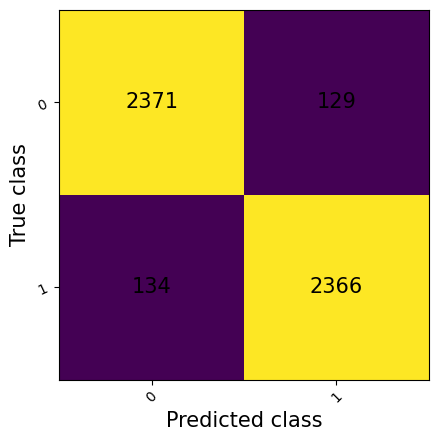

In [15]:
import torchmetrics
from matplotlib import pyplot
from torch.utils.data import DataLoader

# setting the model to evaluation mode
model.eval()

# initializing metrics calculators
accuracy = torchmetrics.Accuracy(task="binary").to(device)
precision = torchmetrics.Precision(task="binary").to(device)
recall = torchmetrics.Recall(task="binary").to(device)
f1 = torchmetrics.F1Score(task="binary").to(device)
confusion_matrix = torchmetrics.classification.MulticlassConfusionMatrix(num_classes=2).to(device)

# Iterate through the dataset and compute metrics
with torch.no_grad():
    for inputs, labels in validation_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs).squeeze()
        outputs = torch.where(outputs > 0.5, torch.tensor(1), torch.tensor(0))

        accuracy.update(outputs, labels)
        precision.update(outputs, labels)
        recall.update(outputs, labels)
        f1.update(outputs, labels)
        confusion_matrix.update(outputs, labels)


accuracy_value = accuracy.compute()
precision_value = precision.compute()
recall_value = recall.compute()
f1_value = f1.compute()

# Print or use the metrics as needed
print(f"Accuracy: {accuracy_value:.4f}")
print(f"Precision: {precision_value:.4f}")
print(f"Recall: {recall_value:.4f}")
print(f"F1 Score: {f1_value:.4f}")
fig, ax = confusion_matrix.plot()

In [31]:
torch.save(model, 'pytorch_model1.pth')
# saving the model's state_dict
torch.save(model.state_dict(), 'pytorch_model_state_dict1.pth')

In [14]:
model = MyModel()
model = torch.load("pytorch_model.pth").to('cuda')
model.eval()

MyModel(
  (conv1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv4): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=